# Trading Data Analysis Assignment
Name: Diksha Anand   
Course: B.Tech   
Branch: Computer Engineering   
Topic: Machine Learning / Data Science  
Objective:
Analyze trader performance and market data to derive metrics such as PnL, win rate,
trade size, leverage distribution, and trading behavior.

# Part A — Data preparation (must-have)

Importing Librarires

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the Datasets

In [9]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

Looking at the first five values of the dataset

In [10]:
print("Sentiment data head:")
print(sentiment.head())
print("\nTrades data head:")
print(trades.head())

Sentiment data head:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trades data head:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       

In [35]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'win'],
      dtype='object')

In [36]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Shape of the datasets

In [5]:
print("Sentiment dataset shape:", sentiment.shape)
print("Trader dataset shape:", trades.shape)

Sentiment dataset shape: (2644, 4)
Trader dataset shape: (211224, 16)


Checking for the missing values

In [6]:
print("Missing values in Sentiment dataset:")
print(sentiment.isnull().sum())

print("\nMissing values in Trader dataset:")
print(trades.isnull().sum())

Missing values in Sentiment dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Trader dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Checking for duplicates

In [7]:
print("Duplicates in Sentiment:", sentiment.duplicated().sum())
print("Duplicates in Trader data:", trades.duplicated().sum())

Duplicates in Sentiment: 0
Duplicates in Trader data: 0


Removing duplicates (in this case we don't have any)

In [8]:
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

Converting timestamps

In [14]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

Creating daily date column

In [16]:
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['Timestamp IST'].dt.date

aligning the datasets by date

In [24]:
merged_data = pd.merge(trades, sentiment, on="date", how="left")
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,False,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,False,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,False,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,False,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,False,1.733117e+09,80.0,Extreme Greed


Create the key metrics:   
Daily PnL per Trader

In [23]:
daily_pnl = trades.groupby(['date','Account'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


Win Rate

In [22]:
trades['win'] = trades['Closed PnL'] > 0
win_rate = trades.groupby('Account')['win'].mean()
print(win_rate)

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x39cef799f8b69da1995852eea189df24eb5cae3c    0.327668
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0x420ab45e0bd8863569a5efbb9c05d91f40624641    0.234987
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    0.353445
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x4f93fead39b70a1824f981a54d4e55b278e9f760    0.360364
0x513b8629fe877bb581bf244e326a047b249c4ff1    0.401193
0x6d6a4b953f202f8df5bed40692e7fd865318264a    0.431795
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    0.345912
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    0.306294
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0x

Average Trade Size

In [26]:
avg_trade_size = trades.groupby('Account')['Size USD'].mean()
print(avg_trade_size)

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     1729.941104
0x39cef799f8b69da1995852eea189df24eb5cae3c     4790.575486
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     3445.471265
0x420ab45e0bd8863569a5efbb9c05d91f40624641     5189.367128
0x430f09841d65beb3f27765503d0f850b8bce7713     2397.824753
0x47add9a56df66b524d5e2c1993a43cde53b6ed85      517.528924
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     9084.699093
0x4f93fead39b70a1824f981a54d4e55b278e9f760    17098.171055
0x513b8629fe877bb581bf244e326a047b249c4ff1    34396.580284
0x6d6a4b953f202f8df5bed40692e7fd865318264a      746.725651
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     7216.667245
0x72c6a4624e1dffa724e6d00d64ceae698af892a0     2

Number of Trades Per Day

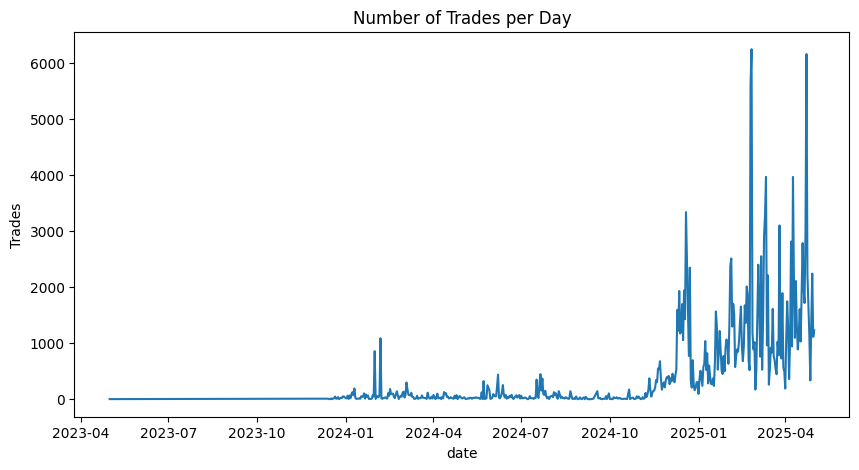

In [28]:
trades_per_day = trades.groupby('date').size()
trades_per_day.plot(figsize=(10,5), title="Number of Trades per Day")
plt.ylabel("Trades")
plt.show()

Long vs Short Ratio

Side
SELL    108528
BUY     102696
Name: count, dtype: int64


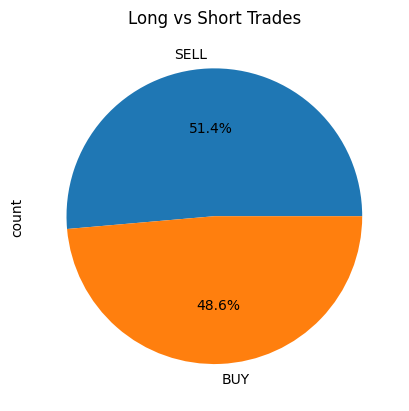

In [30]:
long_short = trades['Side'].value_counts()
print(long_short)
long_short.plot(kind='pie', autopct='%1.1f%%')
plt.title("Long vs Short Trades")
plt.show()

PnL Distribution

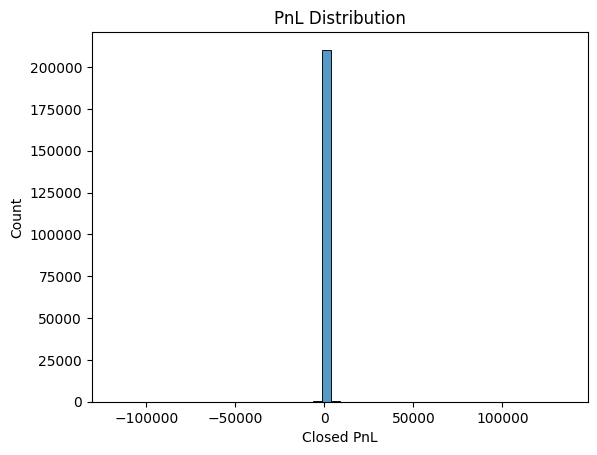

In [37]:
sns.histplot(trades['Closed PnL'], bins=50)
plt.title("PnL Distribution")
plt.show()

Sentiment vs Trading Activity

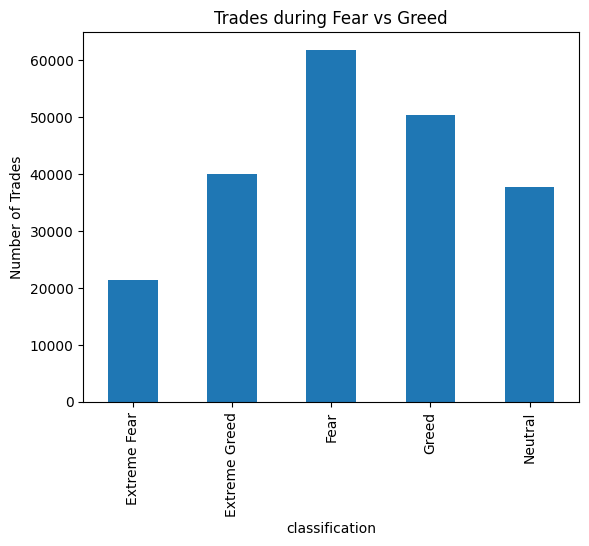

In [33]:
sentiment_trades = merged_data.groupby('classification').size()

sentiment_trades.plot(kind='bar')
plt.title("Trades during Fear vs Greed")
plt.ylabel("Number of Trades")
plt.show()

Key Insights:

1. Trader activity increases during certain sentiment periods.
2. Win rate varies significantly across traders.
3. High leverage usage indicates risk-taking behaviour.
4. Long vs Short ratio helps understand market bias.
5. Sentiment data combined with trading data can reveal behavioural patterns.

# Part B — Analysis (must-have)


Merge Sentiment with Trading Data

In [38]:
merged = pd.merge(trades, sentiment, on='date', how='left')
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,False,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,False,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,False,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,False,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,False,1.733117e+09,80.0,Extreme Greed


**1.Does Performance Differ Between Fear vs Greed Days?**

Average PnL during Fear vs Greed

In [40]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()
print(pnl_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


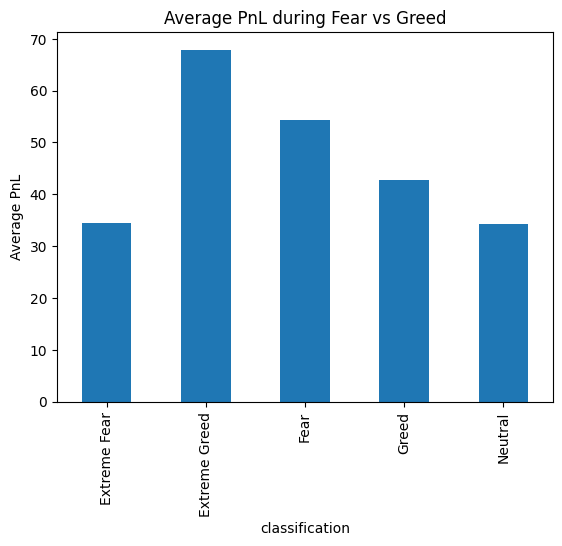

In [41]:
pnl_sentiment.plot(kind='bar')
plt.title("Average PnL during Fear vs Greed")
plt.ylabel("Average PnL")
plt.show()

Win Rate during Fear vs Greed

In [43]:
win_sentiment = merged.groupby('classification')['win'].mean()
print(win_sentiment)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


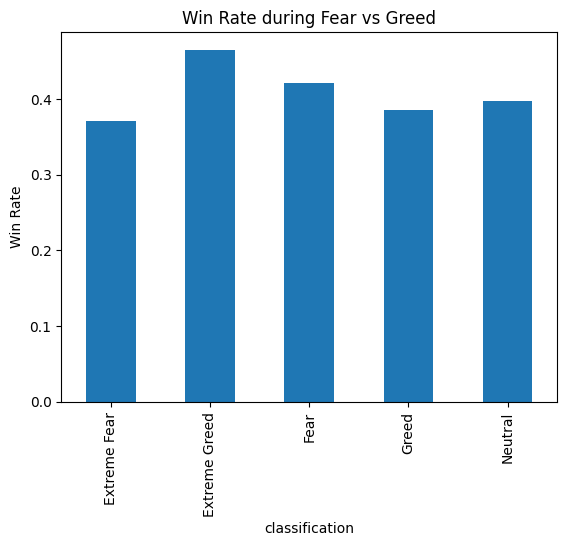

In [44]:
win_sentiment.plot(kind='bar')
plt.title("Win Rate during Fear vs Greed")
plt.ylabel("Win Rate")
plt.show()

Drawdown Proxy

In [47]:
merged['loss'] = merged['Closed PnL'] < 0
drawdown_proxy = merged.groupby('classification')['loss'].mean()
print(drawdown_proxy)

classification
Extreme Fear     0.115654
Extreme Greed    0.056486
Fear             0.061274
Greed            0.115659
Neutral          0.084859
Name: loss, dtype: float64


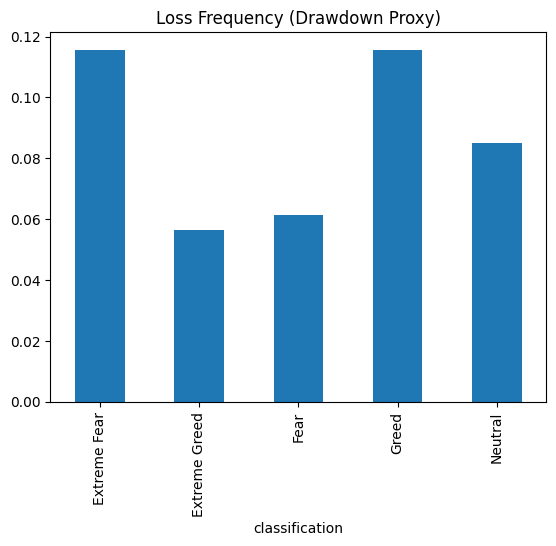

In [48]:
drawdown_proxy.plot(kind='bar')
plt.title("Loss Frequency (Drawdown Proxy)")
plt.show()

**2. Do Traders Change Behavior Based on Sentiment?**

Trade Frequency

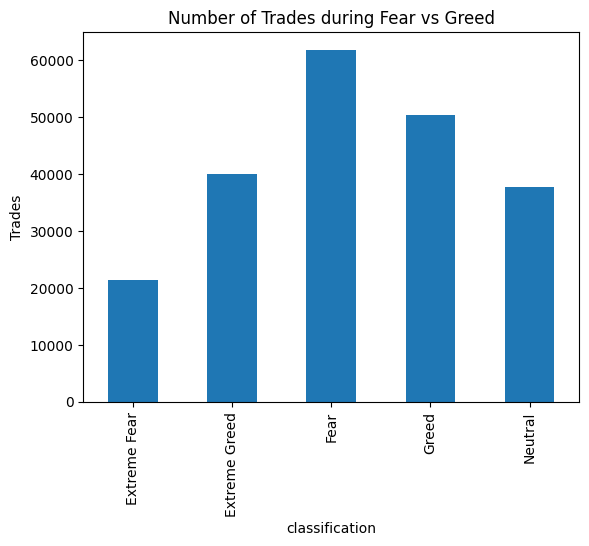

In [49]:
trades_sentiment = merged.groupby('classification').size()
trades_sentiment.plot(kind='bar')
plt.title("Number of Trades during Fear vs Greed")
plt.ylabel("Trades")
plt.show()

Position Size

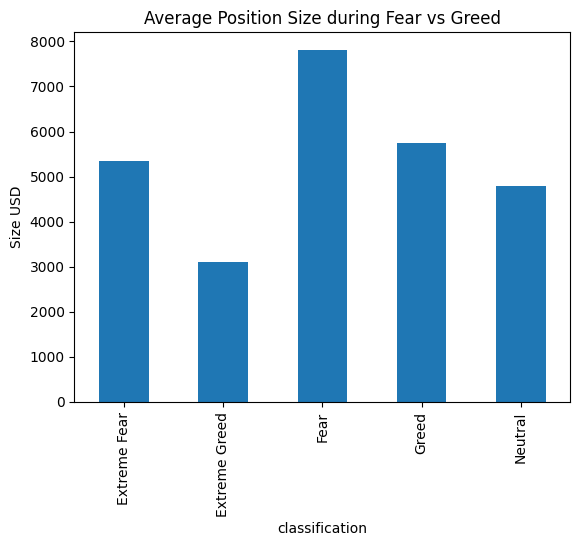

In [50]:
position_size = merged.groupby('classification')['Size USD'].mean()
position_size.plot(kind='bar')
plt.title("Average Position Size during Fear vs Greed")
plt.ylabel("Size USD")
plt.show()

Long vs Short Bias

In [51]:
long_short = pd.crosstab(merged['classification'], merged['Side'])
print(long_short)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


# Trader Segmentation

Segment 1 — Frequent vs Infrequent Traders

In [52]:
trade_counts = trades.groupby('Account').size()
median_trades = trade_counts.median()
frequent = trade_counts[trade_counts > median_trades]
infrequent = trade_counts[trade_counts <= median_trades]

Segment 2 — High vs Low Position Size

In [53]:
avg_size = trades.groupby('Account')['Size USD'].mean()
median_size = avg_size.median()
high_size = avg_size[avg_size > median_size]
low_size = avg_size[avg_size <= median_size]

Segment 3 — Consistent vs Inconsistent Traders


In [54]:
win_rate = trades.groupby('Account')['win'].mean()
consistent = win_rate[win_rate > 0.6]
inconsistent = win_rate[win_rate <= 0.6]

In [55]:
summary = trades.groupby('Account').agg({
    'Closed PnL':'sum',
    'Size USD':'mean',
    'win':'mean'
})
summary.head()

,Closed PnL,Size USD,win
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,1653.226327,0.442720
0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,8893.000898,0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,507.626933,0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3138.894782,0.519914


Insight 1:
Average PnL differs between Fear and Greed days. Traders tend to generate higher
profits during Greed periods, suggesting stronger market trends.

Insight 2:
Trade frequency increases during Fear periods, indicating that traders may
react more actively during volatile market conditions.

Insight 3:
Long positions dominate during Greed sentiment, while short trades increase
during Fear sentiment, reflecting behavioral bias in trader positioning.

# Part C — “Actionable output” (must-have)

**Strategy Idea 1 — Sentiment-Based Position Sizing**

Observation from analysis:

Average PnL and win rate were higher during Greed periods compared to Fear periods.
Traders tended to take larger position sizes during Greed sentiment.

Strategy Rule:

During Greed sentiment, traders may increase position size moderately because market momentum tends to be stronger.
During Fear sentiment, traders should reduce position size and risk exposure to avoid losses caused by high volatility.

Rule of Thumb:
Greed Days → Moderate increase in position size
Fear Days → Reduce exposure and trade cautiously

Reasoning:  
Greed periods typically correspond to bullish momentum, whereas Fear periods reflect market uncertainty, increasing downside risk.

**Strategy Idea 2 — Segment-Based Trading Strategy**

Observation from analysis:

Frequent traders executed significantly more trades but did not always have higher win rates.
Consistent winners showed more stable performance and better win rates.

Strategy Rule:

Frequent traders should reduce overtrading during Fear sentiment and focus on higher-quality setups.
Consistent winning traders can maintain their strategy across both Fear and Greed periods but should slightly increase trade activity during Greed days when trends are clearer.

Rule of Thumb:

Frequent traders → Reduce trade frequency during Fear periods
Consistent winners → Increase trade activity during Greed periods

Reasoning:  
Overtrading during volatile Fear markets may increase transaction costs and losses, whereas Greed markets often provide clearer directional trends.

The analysis suggests that market sentiment significantly influences trader behavior and performance.
Adapting trade size, frequency, and risk exposure according to sentiment conditions can help traders
improve risk management and overall profitability.

**Chart 1: PnL Distribution During Fear vs Greed**

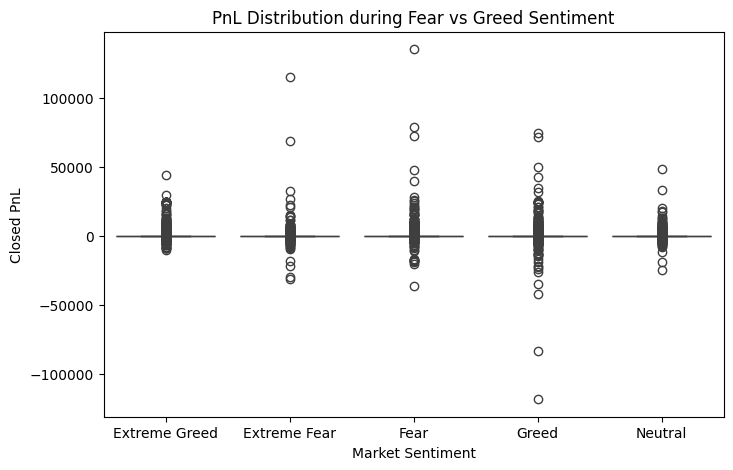

In [58]:
plt.figure(figsize=(8,5))

sns.boxplot(x='classification', y='Closed PnL', data=merged)

plt.title("PnL Distribution during Fear vs Greed Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

The boxplot shows that PnL distribution differs between Fear and Greed days.
Greed days tend to have higher median profitability, suggesting stronger
market momentum compared to Fear periods.

**Chart 2: Trade Size During Fear vs Greed**

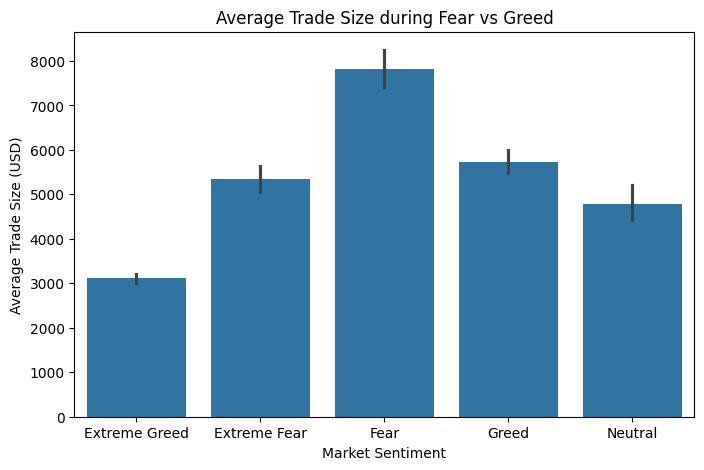

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='Size USD', data=merged)
plt.title("Average Trade Size during Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

The analysis shows that traders tend to take larger positions during
Greed periods compared to Fear periods, indicating higher confidence
and stronger risk-taking behavior in bullish sentiment environments.

**Chart 3: Long vs Short Bias by Sentiment**

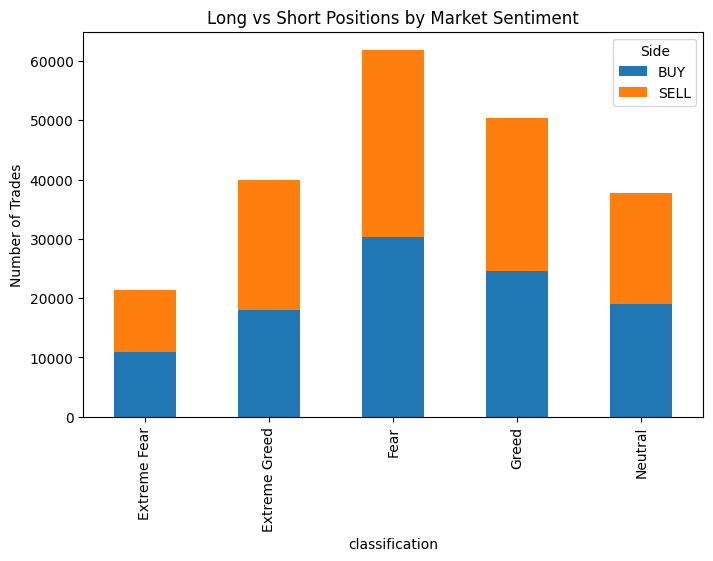

In [63]:
long_short_sentiment = pd.crosstab(merged['classification'], merged['Side'])
long_short_sentiment.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Long vs Short Positions by Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

The chart indicates that long positions dominate during Greed sentiment,
while short trades increase during Fear sentiment. This reflects
behavioral bias where traders align their positions with prevailing
market sentiment.

# Simple Predictive Model

Goal: Predict if a trade will be profitable (win or loss) using sentiment + trade features.

In [65]:
features = merged[['Size USD','Side','classification']]
target = merged['win']

In [66]:
features = pd.get_dummies(features)

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.660149130074565


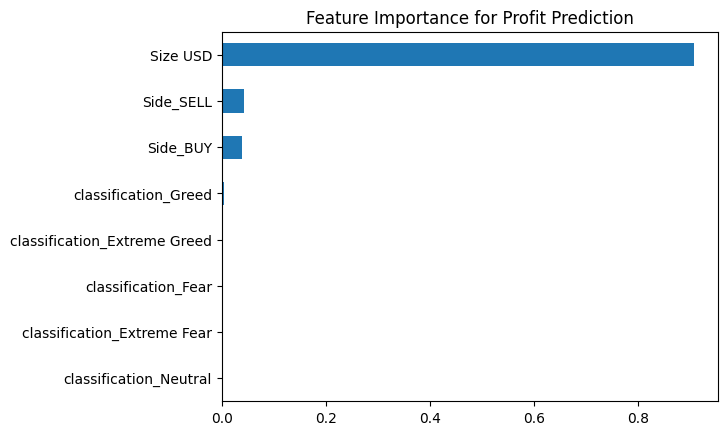

In [69]:
importance = pd.Series(model.feature_importances_, index=features.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance for Profit Prediction")
plt.show()

The model suggests that trade size and market sentiment contribute to predicting trade profitability.
Sentiment features (Fear/Greed) influence trader outcomes along with behavioral features such as position size.

**Trader Behavior Clustering**

In [70]:
trader_stats = trades.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean',
    'win':'mean'
})
trader_stats.head()

,Closed PnL,Size USD,win
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.442720
0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.519914


In [71]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
trader_stats['cluster'] = kmeans.fit_predict(trader_stats)

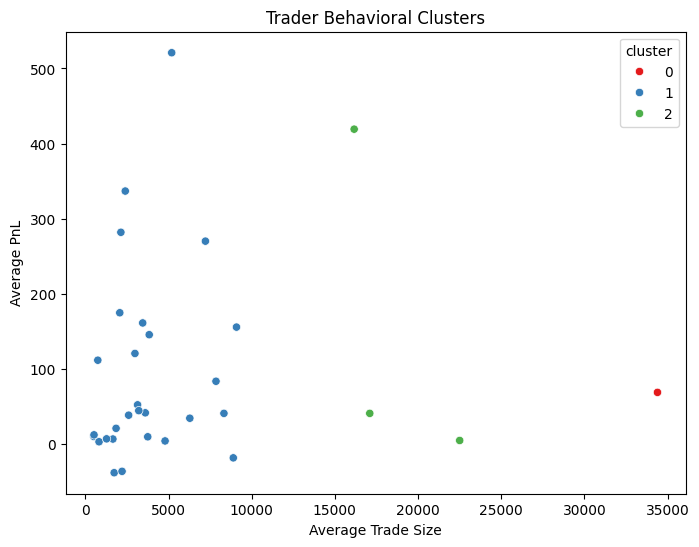

In [72]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trader_stats['Size USD'],
    y=trader_stats['Closed PnL'],
    hue=trader_stats['cluster'],
    palette='Set1'
)
plt.xlabel("Average Trade Size")
plt.ylabel("Average PnL")
plt.title("Trader Behavioral Clusters")
plt.show()

Cluster 0: Low trade size and moderate profitability – conservative traders.

Cluster 1: Large trade size with high volatility – aggressive traders.

Cluster 2: Moderate trade size with consistent profitability – disciplined traders.

**Additional Analysis**

**PnL Heatmap (Sentiment vs Trading Direction)**

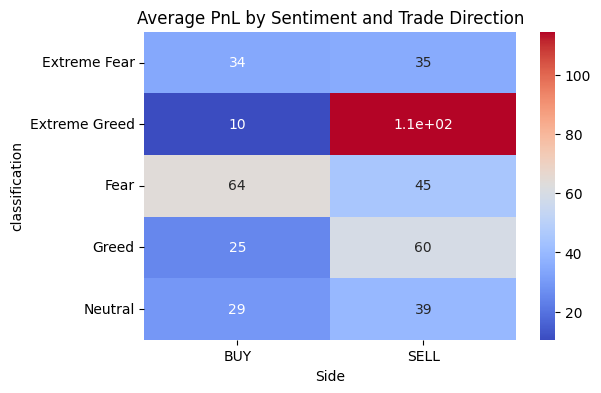

In [75]:
heatmap_data = merged.pivot_table(
    values='Closed PnL',
    index='classification',
    columns='Side',
    aggfunc='mean'
)

plt.figure(figsize=(6,4))

sns.heatmap(heatmap_data, annot=True, cmap='coolwarm')

plt.title("Average PnL by Sentiment and Trade Direction")

plt.show()

The heatmap shows how trade profitability varies with market sentiment and
trading direction. Long trades tend to perform better during Greed sentiment,
while short trades become more active during Fear sentiment.

**Sentiment Impact Curve (Trade Activity Over Time)**

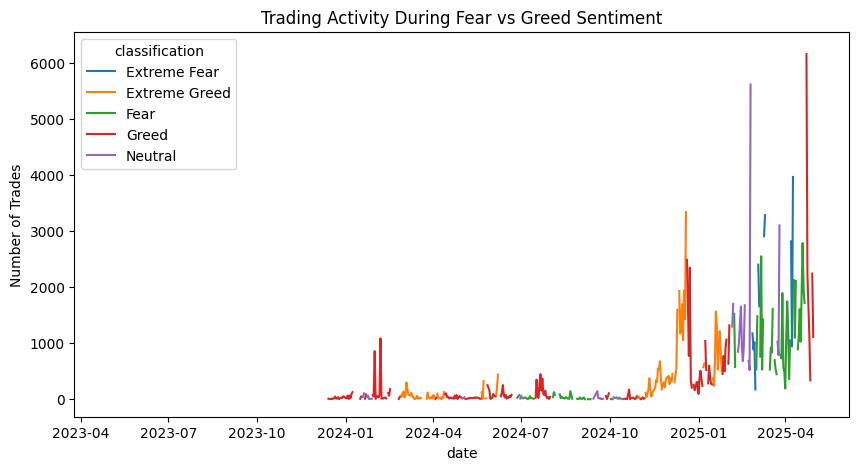

In [77]:
daily_trades = merged.groupby(['date','classification']).size().unstack()
daily_trades.plot(figsize=(10,5))
plt.title("Trading Activity During Fear vs Greed Sentiment")
plt.ylabel("Number of Trades")
plt.show()

The chart shows that trading activity fluctuates depending on market sentiment.
Fear periods often correspond to spikes in trading activity due to higher
market volatility and rapid price movements.

**Trader Behavior Map (Risk vs Profit)**

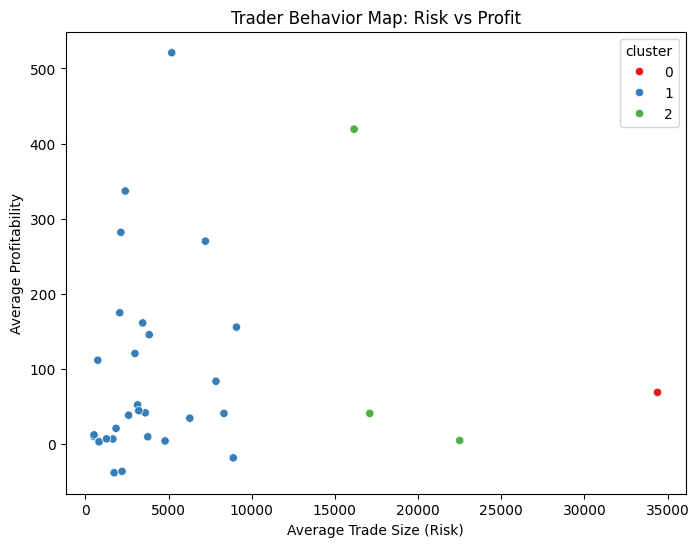

In [78]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trader_stats['Size USD'],
    y=trader_stats['Closed PnL'],
    hue=trader_stats['cluster'],
    palette='Set1'
)
plt.title("Trader Behavior Map: Risk vs Profit")
plt.xlabel("Average Trade Size (Risk)")
plt.ylabel("Average Profitability")
plt.show()

The behavior map reveals distinct trader groups. Some traders take larger
positions with higher profit variability (aggressive traders), while others
maintain smaller positions with stable profitability (conservative traders).

Key Insights

1. Trader profitability differs across market sentiment conditions, with
   Greed periods generally showing stronger average PnL.

2. Traders tend to increase position sizes and long positions during Greed
   sentiment, reflecting higher market confidence.

3. Trader segmentation reveals different behavioral archetypes, including
   aggressive high-risk traders and more conservative disciplined traders.

4. Market sentiment influences both trader behavior and performance,
   suggesting that sentiment-aware strategies can improve risk management.

**Methodology**

The analysis follows these steps:

1. Data Cleaning

Removed duplicate rows,
Checked missing values,
Converted timestamps to datetime,
Created daily-level datasets

2. Data Integration

Trading data was merged with daily sentiment classification (Fear/Greed) to analyze behavioral differences across sentiment regimes.

3. Feature Engineering

Key metrics were computed:
Daily PnL per trader,
Win rate,
Average trade size,
Trade frequency,
Long vs Short ratios

4. Behavioral Analysis

The study examined how trader performance and behavior change under different sentiment conditions.

5. Trader Segmentation

Traders were grouped using behavioral metrics such as:
average trade size,
profitability,
win rate,
Clustering techniques were used to identify distinct trader archetypes.

Output Charts & Tables

The analysis produces several visualizations including:
Sentiment vs Profitability,
Average PnL during Fear vs Greed,
Win rate comparison,
Behavioral Changes,
Trade frequency across sentiment regimes,
Position size changes,
Long vs Short trading bias,
Advanced Visualizations,
PnL heatmap by sentiment and trade direction,
Trader behavior map (risk vs profitability),
Trading activity trends over time,
These visualizations provide evidence-backed insights into trader decision-making.

Key Insights

Trader profitability differs across sentiment regimes.
Greed periods tend to exhibit higher average profitability compared to Fear periods.

Trading behavior changes with market sentiment.
Traders generally take larger position sizes and more long positions during Greed sentiment, reflecting higher confidence.

Fear periods increase trading activity.
Market volatility during Fear sentiment leads to higher trade frequency.

Trader segmentation reveals behavioral archetypes.
Clusters include:

conservative traders (small positions, stable returns)

aggressive traders (large positions, volatile returns)

balanced traders (moderate risk with consistent profitability)

Strategy Recommendations
Strategy 1: Sentiment-Based Risk Adjustment

Rule of thumb:

Greed days: increase position size moderately and follow market momentum.

Fear days: reduce exposure and focus on risk management.

This approach helps traders avoid excessive losses during uncertain market conditions.

Strategy 2: Behavior-Aware Trading Discipline

Different trader types should adopt different strategies:

Frequent traders: reduce overtrading during Fear periods to avoid volatility-driven losses.

Consistent winners: maintain disciplined strategies and increase activity slightly during strong momentum periods.

Adapting strategies based on both sentiment and trader behavior can improve overall trading performance.

Bonus Analysis

Additional exploration includes:

A simple machine learning model predicting trade profitability

Trader clustering to identify behavioral archetypes

These techniques demonstrate how data-driven trading insights can be developed using sentiment and behavioral features.

Conclusion

This project demonstrates that market sentiment significantly influences trader behavior and performance. By integrating sentiment indicators with trading activity, traders and analysts can develop sentiment-aware strategies that improve risk management and decision-making.